In [ ]:
%reload_ext autoreload
%autoreload 2

# --- imports --
import radial_functions as radial
import matplotlib.pyplot as plt
from IPython.display import display, HTML


# Some parameters used for tolerance in numerical computations
EPS = 1e-12
TOL = 1e-9

---
# 2 A system with radial symmetry
---

We consider the radial equation:
$$
\dot r=\mu r+r^3-r^5 \;=\; r(\mu+r^2-r^4)
$$
with $\mu\in\mathbb{R}$ the parameter of the system.

Viewed as a 1D dynamical system in $r\ge 0$, the goal is to find the equilibria $r_{eq}$, classify their stability from the sign of $f'(r_{eq})$, and determine for which values of $\mu$ the number and stability of equilibria change, which means that we will identify the bifurcations.

To translate this to a 2D radially symmetric setting, we embed the dynamics in polar coordinates $(r,\theta)$ and prescribe a nontrivial angular motion (e.g. $\dot\theta=\omega\neq 0$). Then $r(t)$ controls the distance to the origin while $\theta(t)$ rotates the trajectory. In this interpretation, $r=0$ corresponds to the fixed point at the origin, and any nonzero constant radius $r_{eq}$ corresponds to a circular periodic orbit (limit cycle) of radius $r_{eq}$, whose stability is inherited directly from the 1D stability of $r_{eq}$. We will visualize the different $\mu$-regimes using a phase line for $r$ and phase portraits in $(x,y)$ with $r=\sqrt{x^2+y^2}$ and an initial angular velocity $\dot\theta\neq 0$.

---
## 2.1 1D Radius Dynamics: Equilibria and Bifurcation Structure
---

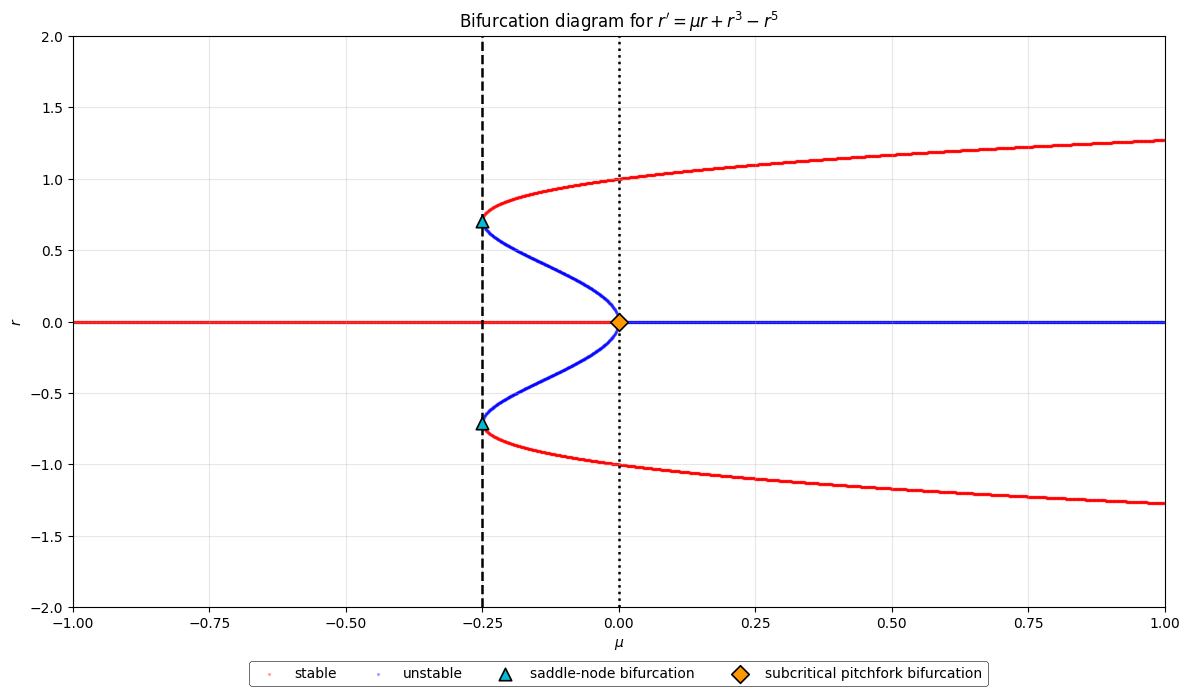

In [37]:
fig = radial.plot_bifurcation_1d(mu_range=(-1, 1), r_range=(-2, 2), n_mu=3000, legend=True, include_negative=True)
ax = plt.gca()
leg = ax.get_legend()
if leg:
    for text in leg.get_texts():
        if "Hopf" in text.get_text():
            text.set_text("subcritical pitchfork bifurcation") 
plt.show()

As $\mu$ varies the system experiences two key changes. At $\mu = -\tfrac{1}{4}$ a saddle‑node occurs. A pair of nonzero equilibria meet at $r = \pm\tfrac{1}{\sqrt{2}}$, for $\mu < -\tfrac{1}{4}$ no nonzero equilibria remain, while for $-\tfrac{1}{4} < \mu < 0$ the pair splits into an unstable inner branch and a stable outer branch, with stability given by $f'(r) = \mu + 3r^2 - 5r^4$. At $\mu = 0$ symmetry produces a subcritical pitchfork at the origin: the origin flips stability and the small amplitude nonzero branch that exists for $\mu < 0$ is unstable and terminates at $r = 0$. For $\mu > 0$ only the stable outer branchremains, and the inner expression becomes imaginary in $r$ so no inner equilibrium exists.

**Sources**:
>Section [1.2 Transcritical and pitchfork bifurcations](https://ocw.mit.edu/courses/12-006j-nonlinear-dynamics-chaos-fall-2022/mit12_006jf22_lec10-11.pdf)

> Due to the $x^5$ term, the unstable branches turn around and become stable at $\mu = -\frac{1}{4} < 0$.
>
>Section [Stabilizing and destabilizing inﬂuence](Examen/Exam-part-2/examen-part2.pdf)

We zoom in on the bifurcations to see how the branches and their stability evolve near $\mu=-1/4$ and $\mu=0$.

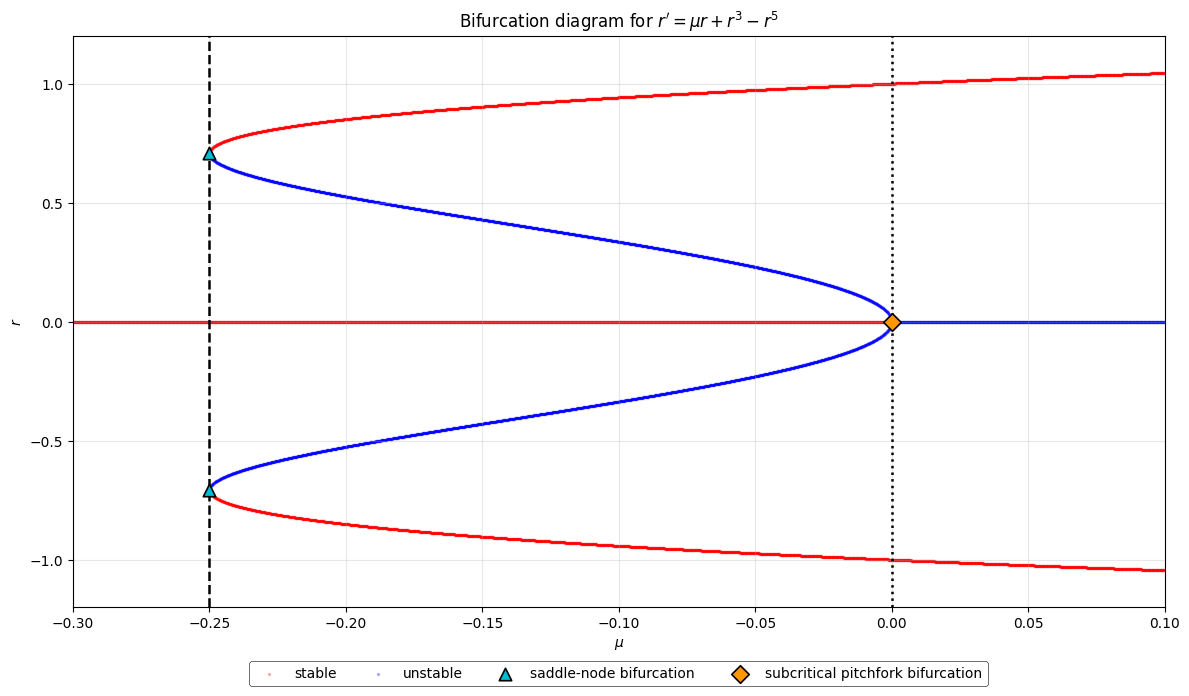

In [38]:
plt.close('all')
fig = radial.plot_bifurcation_1d(mu_range=(-0.3, 0.1), r_range=(-1.2, 1.2), n_mu=3000, legend=True, include_negative=True)
ax = plt.gca()
leg = ax.get_legend()
if leg:
    for text in leg.get_texts():
        if "Hopf" in text.get_text():
            text.set_text("subcritical pitchfork bifurcation")
plt.show()

In the refined plot, red markers trace the stable equilibria (real parts $\le 0$, trajectories spiral inward), blue markers the unstable ones (real parts $>0$, trajectories spiral outward), and the dotted curve marks $\text{Re}(\lambda)=0$. At $\mu=-1/4$ and $\mu=0$ the real parts hit zero, signaling the saddle-node creation of the two nonzero branches and the pitchfork flip at the origin.

A subcritical branch structure produces hysteresis: starting near the origin with $r<0$, the state stays at the origin until $\mu$ reaches 0, where loss of stability forces a jump to the large-amplitude branch. As $\mu$ increases further it tracks that outer branch; when $\mu$ is decreased again the system remains on the large-amplitude branch even for $\mu<0$, only jumping back when $\mu$ is driven past the saddle-node at $\mu=-1/4$. This irreversibility of the up/down parameter sweep is the hallmark of hysteresis.

The eigenvalues determine stability of equilibria. For a circular equilibrium at radius $r_{eq}$, the linearized eigenvalues are:
$$\lambda = \left(\frac{\partial f}{\partial r}\bigg|_{r=r_{eq}}\right) \pm i\omega$$

where $\frac{\partial f}{\partial r}$ is computed numerically using finite differences via the Jacobian.

The real part determines radial stability either attraction orrepulsion


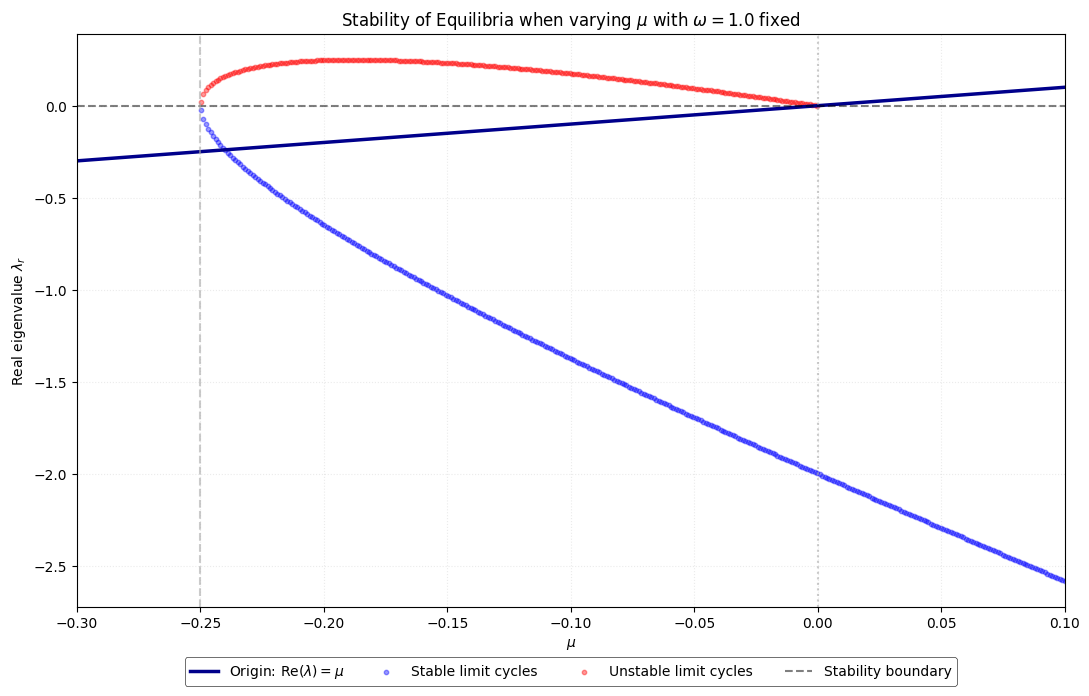

In [40]:
radial.plot_eigenvalues_vs_mu(mu_range=(-0.3, 0.1), n_points=400, omega=1.0)
plt.show()

The blue line tracks the real eigenvalue of the origin, stable for $\mu<0$ and unstable for $\mu>0$. Blue dots mark the real parts of stable circular equilibria. Nonpositive real eigenvalues means that the trajectories spiral inward. The red dots mark unstable limit cycles. Positive real eigenvalues means that trajectories spiral outward and serve as separatrices. Vertical dashed guides at $\mu=-1/4$ and $\mu=0$ flag where equilibria are created or change stability. A saddle-node introduces the two nonzero branches at $\mu=-1/4$, and at $\mu=0$ the origin flips stability in a subcritical pitchfork/Hopf correspondence.

---
## 2.2 2D Interpretation: Invariant Circles, Phase Portraits, and the Role of $\dot\theta\neq 0$
---

Starting from the radial equation $\dot{r} = \mu r + r^3 - r^5$, we study equilibria for both positive and negative $r$. To place this 1D radial flow into a 2D system, we adopt polar coordinates $(r,\theta)$ with a prescribed angular speed $\dot{\theta} = \omega$ while the radius still follows $\dot{r} = \mu r + r^3 - r^5$. In the Cartesian plane this corresponds to circular motion with growth or decay in $r$, so the radial equilibria become invariant circles whose stability matches the 1D analysis.

Converting to **Cartesian coordinates** $(x, y)$ where $r = \sqrt{x^2 + y^2}$:

$$
\begin{align}
\frac{dx}{dt} &= \frac{f(r, \mu)}{r} \cdot x - \omega y \\
\frac{dy}{dt} &= \frac{f(r, \mu)}{r} \cdot y + \omega x
\end{align}
$$

where $f(r, \mu) = \mu r + r^3 - r^5$.

In this form $r = 0$ means a fixed point at the origin no rotation, just equilibrium.
Any $r = r_{eq} > 0$ becomes a **limit cycle**, a circular periodic orbit of radius $r_{eq}$.

The stability of the limit cycle inherits directly from the 1D stability of $r_{eq}$:

| Condition on $f'(r_{eq})$ | Stability of the limit cycle | Trajectory behavior |
| --- | --- | --- |
| $f'(r_{eq}) < 0$ | Stable | Trajectories spiral toward the circle |
| $f'(r_{eq}) > 0$ | Unstable | Trajectories spiral away from the circle |

In [46]:
display(HTML("""
<div style="display:flex; gap:16px;">
    <img src="The-Hopf-bifurcation-a-Supercritical-b-subcritical-Thompson-and-Stewart-1986.png" style="width:25%;">
    <img src="example-subcrithopf.png" style="width:25%;">          
</div>
"""))

The figures above illustrates the distinction between **supercritical** and **subcritical Hopf bifurcations**. Our system exhibits the **subcritical case**. With this figure, I want to show you visually what we are doing when we move from our 1D case to a 2D case.

For a **supercritical Hopf bifurcation**, as $\mu$ increases through zero, a **small-amplitude limit cycle** is created *at the bifurcation point* and it is **stable**. At the same time, the equilibrium at the origin loses stability in a smooth way. It transitions from **stable** to **unstable**, while the newly born stable cycle governs the nearby dynamics.

For a **subcritical Hopf bifurcation**, an **unstable limit cycle** already exists for $\mu < 0$, typically with a **finite amplitude**, and it **shrinks** as $\mu$ approaches zero. At $\mu = 0$, this unstable cycle collides with the equilibrium, and the equilibrium loses stability at the same point. This setup can produce **hysteresis**. Trajectories that start near the equilibrium may suddenly jump to a distant **stable** limit cycle once $\mu$ crosses zero, rather than growing gradually from infinitesimal oscillations.

In our radial system, this subcritical structure manifests as the **saddle-node of cycles** at $\mu = -\frac{1}{4}$, where two nonzero equilibria corresponding to circular limit cycles in 2D are created. The inner, unstable cycle acts as the separatrix, while the outer cycle is stable. At $\mu = 0$, the inner cycle collapses onto the origin precisely matching the subcritical Hopf geometry shown here

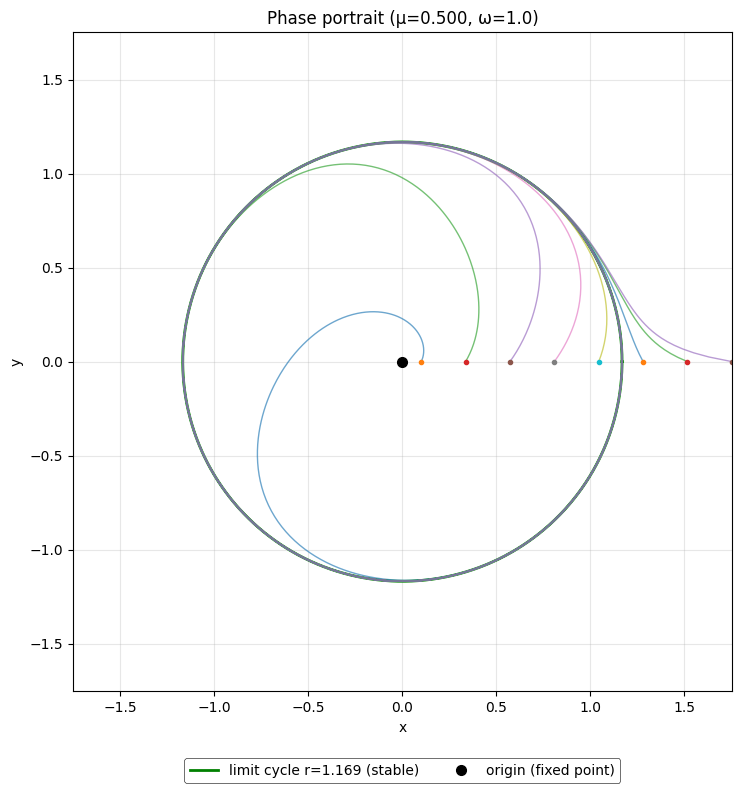

In [43]:
radial.plot_phase_portrait(mu=0.5, omega=1.0, n_trajectories=8, t_max=30)
plt.show()

We will now visualize the 2D phase portraits for three particular cases.

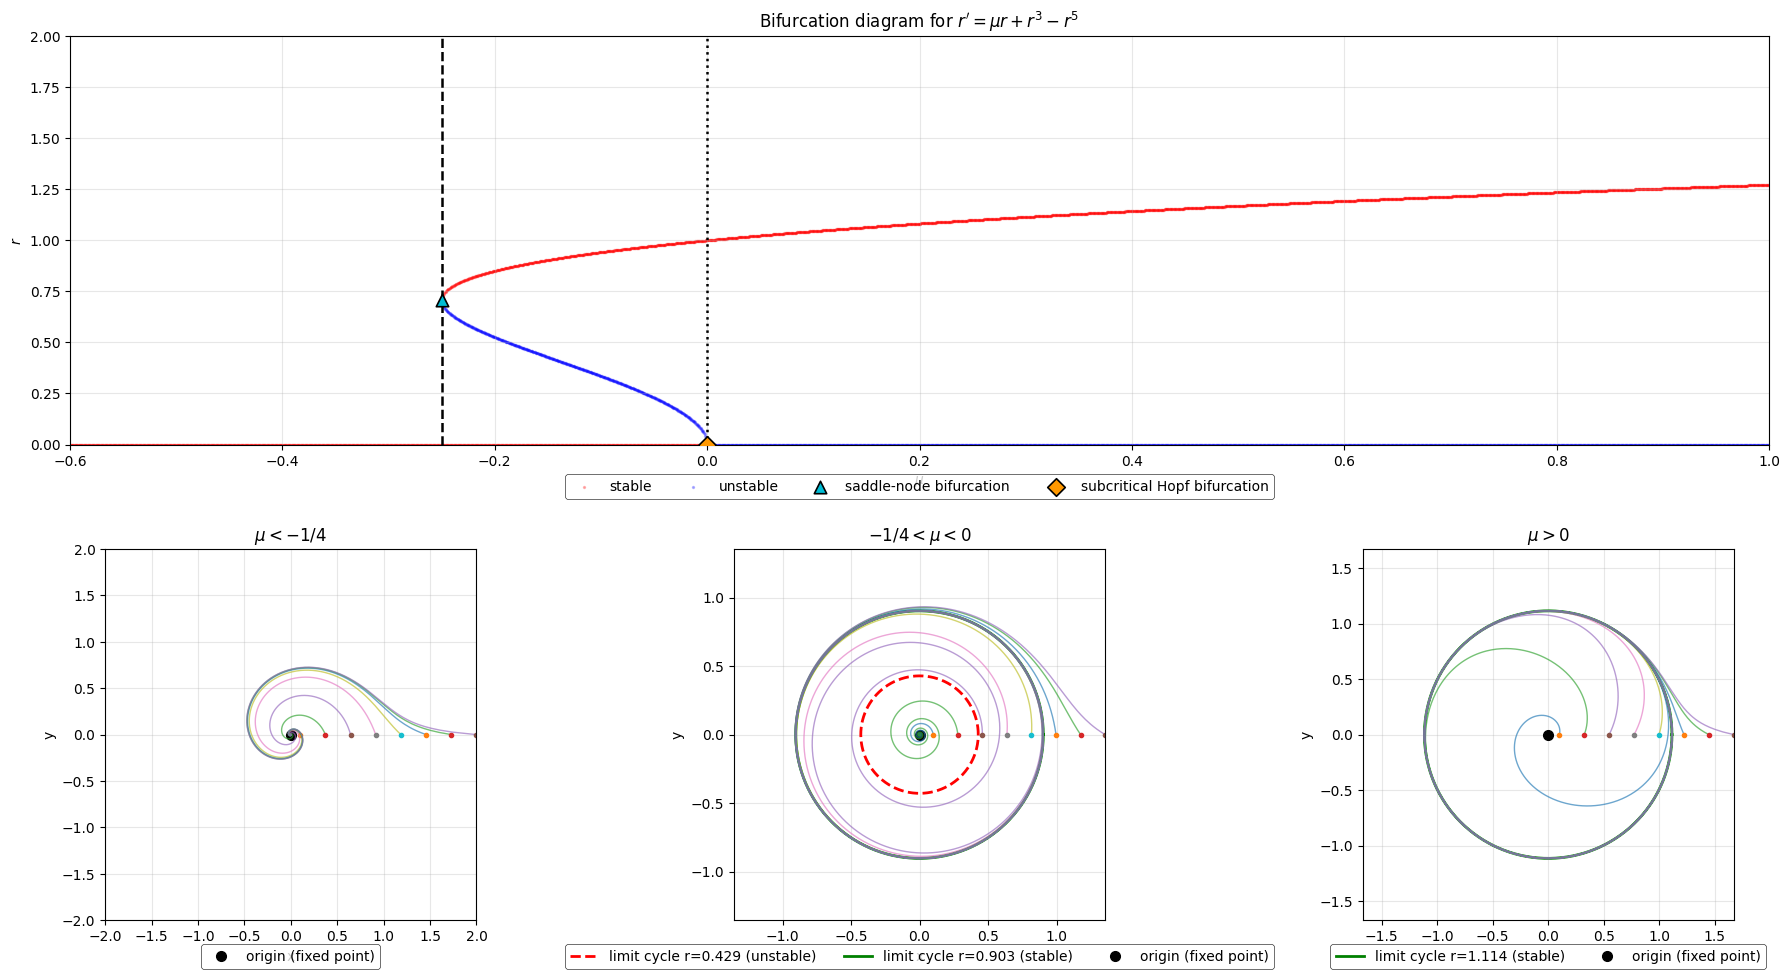

In [45]:
radial.plot_three_regimes()
plt.show()

On the figures above, we see three different cases. For $\mu < -1/4$, only the origin exists and it is globally stable. For $-1/4 < \mu < 0$, the origin stays stable while two limit cycles emerge, an inner unstable circle that acts as a separatrix and an outer stable circle that attracts trajectories. Once $\mu > 0$, the origin becomes unstable and the outer stable limit cycle is the only attractor. Next section we will dive more into these cases. Note that we only how $r \ge 0$ because $x$ and $y$ are real because they represent [euclidian distance](https://en.wikipedia.org/wiki/Euclidean_distance), so by definition $r$ cannot be negative.

Let's visualize how $r(t)$ evolves over time for different initial conditions, showing how trajectories approach stable limit cycles or diverge from unstable ones.

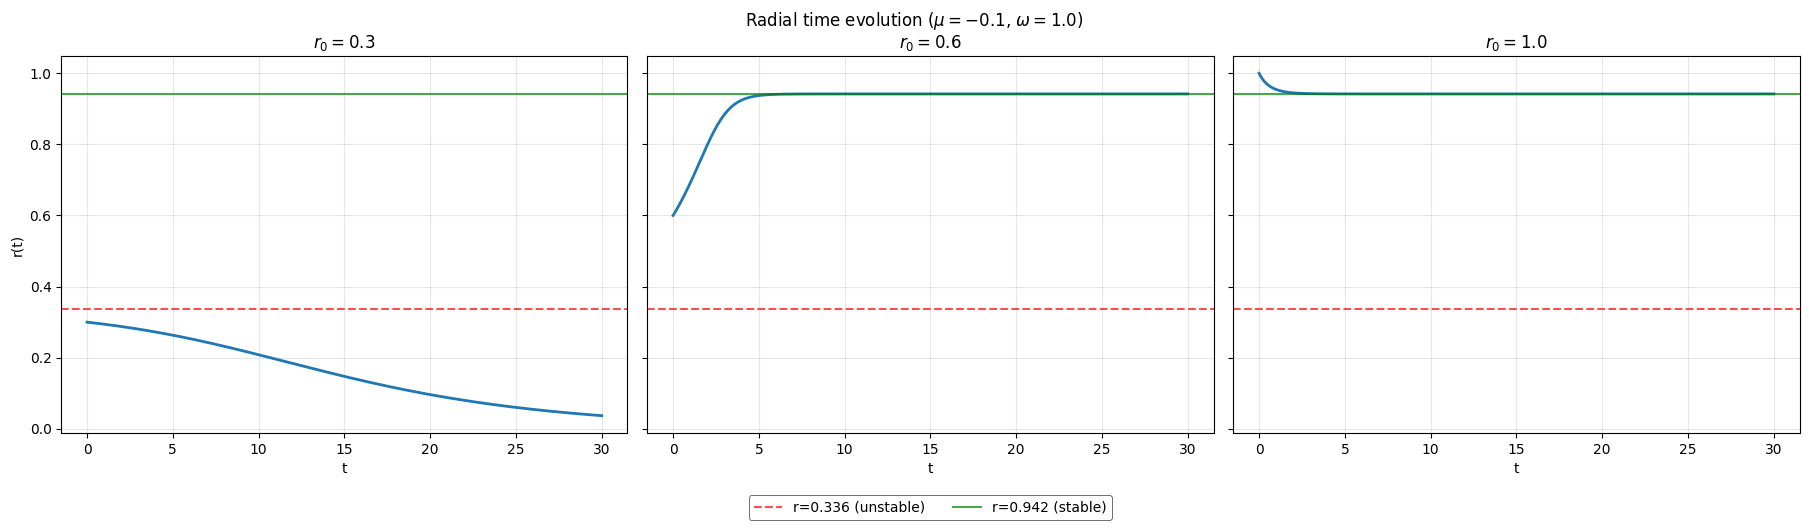

In [35]:
radial.plot_radial_time_subplots(mu=-0.1, initial_radii=[0.3, 0.6, 1.0], omega=1.0, t_max=30)
plt.show()

When $\omega\neq 0$, trajectories no longer move straight in or out but spiral, so the equilibrium radii manifest as circular limit cycles. A stable limit cycle pulls trajectories from both sides. Those starting inside spiral outward to it, and those starting outside spiral inward. An unstable limit cycle does the opposite and acts as a separatrix, pushing nearby trajectories away either inward toward the origin or outward toward the outer stable cycle. In parameter ranges with multiple cycles, that unstable circle is the dividing boundary between domains of attraction.

---
## 2.3 Global Narrative: Stability Regions, Separatrices, and What the System Does in Each Regime
---

The radial equation $\dot{r} = \mu r + r^3 - r^5$ exhibits bifurcation behavior as $\mu$ varies. We identify three distinct cases separated by two critical bifurcation points.

To understand where equilibria appear, disappear, or change stability, we solve the stationarity condition $\mu + r^2 - r^4 = 0$ for $r > 0$. Writing $u = r^2$ reduces this to the quadratic $u^2 - u - \mu = 0$ with solutions $u = \tfrac{1 \pm \sqrt{1 + 4\mu}}{2}$. Real, positive radii require $1 + 4\mu \ge 0$, so equilibria beyond the origin only exist for $\mu \ge -\tfrac{1}{4}$. At the lower threshold $\mu = -\tfrac{1}{4}$ a saddle-node collision occurs at $r = 1/\sqrt{2}$: for $\mu < -\tfrac{1}{4}$ there are no nonzero equilibria, while for $\mu > -\tfrac{1}{4}$ two distinct nonzero radii emerge. The symmetry $f(-r,\mu) = -f(r,\mu)$ implies a local normal form $\dot r \approx \mu r + r^3$ at the origin, so at $\mu = 0$ the origin changes stability via a subcritical pitchfork in 1D corresponding to a subcritical Hopf in 2D. The $-r^5$ term saturates growth and, together with $r^3$, is what produces the saddle-node for $\mu < 0$ and the overall shape of the branches.

#### Case 1: $\mu < -\frac{1}{4}$ **No nonzero equilibria**

In this regime the only equilibrium is the origin, and it is stable since $f'(0) = \mu < 0$. Interpreted in 2D with $\omega \neq 0$, the origin is a globally attracting fixed point. All trajectories spiral inward as the angle rotates, and no limit cycles exist. Physically, regardless of the initial condition the system relaxes monotonically to rest at the origin, with the spiral motion coming purely from the nonzero angular speed.

#### Case 2: $-\frac{1}{4} < \mu < 0$ **Two nonzero equilibria and origin**

In this bistable window the origin remains stable while two nonzero radii coexist: an inner circle at $r_{\text{inner}} = \sqrt{\tfrac{1 - \sqrt{1+4\mu}}{2}}$ and an outer circle at $r_{\text{outer}} = \sqrt{\tfrac{1 + \sqrt{1+4\mu}}{2}}$. Linear stability shows the inner circle is repelling and the outer circle attracting, so the inner limit cycle acts as a separatrix that partitions phase space. Initial radii inside the separatrix ($r_0 < r_{\text{inner}}$) spiral toward the origin, whereas radii outside ($r_0 > r_{\text{inner}}$) spiral toward the outer stable cycle. This tipping-point behavior means small changes across the unstable circle lead to qualitatively different long‑term outcomes rest at the origin versus sustained oscillation on the outer limit cycle.

#### Case 3: $\mu > 0$ **one nonzero equilibrium and unstable origin**

Once $\mu$ becomes positive the origin is unstable ($f'(0) = \mu > 0$) and only one nonzero equilibrium remains. The outer, stable circle at $r_{\text{stable}} = \sqrt{\tfrac{1 + \sqrt{1+4\mu}}{2}}$. The inner expression is imaginary and thus absent. In the 2D picture the origin repels and all trajectories with $r_0 > 0$ spiral outward until they settle on that unique stable limit cycle. Nonlinearity through the $-r^5$ term limits growth and produces a finite-amplitude oscillation, consistent with a subcritical Hopf at $\mu = 0$ in which small cycles are unstable for $\mu < 0$ while a larger, stable cycle exists thanks to a saddle-node of cycles in the negative-$\mu$ range.

### Conclusion

The bifurcation diagram is symmetric in $\pm r$, so every positive branch has a mirrored negative branch with the same stability.

At $\mu = -1/4$ a saddle-node creates a pair of equilibria near $r \approx 1/\sqrt{2}$; for $-1/4 < \mu < 0$ the inner branch is unstable and bends toward $r \to 0$ while the outer branch is stable and grows with $\mu$. At $\mu = 0$ the subcritical pitchfork at the origin ends the small, unstable branch and in 2D corresponds to the origin losing stability in a subcritical Hopf.

The three cases we discussed above follow from that picture. For $\mu < -1/4$ only the stable origin exists, for $-1/4 < \mu < 0$ the stable origin coexists with a stable outer limit cycle separated by an unstable inner cycle and for $\mu > 0$ the origin is unstable and all initial radii $r_0 > 0$ spiral to the single stable outer limit cycle.